# Milestone 4 (v0.2) — Zero-Shot Power Flow Evaluation


In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import dataset as ds, encoding as enc, evaluate as ev
from gridfm.model import GridFMv01, GridFMv02

PROC_DIR = ROOT / "data" / "processed"
RAW_DIR = ROOT / "data" / "raw"
CKPT_DIR = ROOT / "checkpoints"
M5_STATS = ROOT / "results" / "m5_stats"          # committed v0.1 results (frozen)
FIG_DIR = ROOT / "results" / "figures" / "v02_m4"
STATS_DIR = ROOT / "results" / "v02_m4_stats"
for d in [FIG_DIR, STATS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

GRIDS = ["case24", "case30", "case118"]
GRID_COLORS = {"case24": "#4269D0", "case30": "#EFB118", "case118": "#FF725C"}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model_v02 = GridFMv02()
model_v02.load_state_dict(torch.load(CKPT_DIR / "final_pretrain_v02_best.pt",
                                     weights_only=False)["model"])
model_v01 = GridFMv01()
model_v01.load_state_dict(torch.load(CKPT_DIR / "final_pretrain_best.pt",
                                     weights_only=False)["model"])

test_plain, test_v02 = {}, {}
res02, det02 = {}, {}
for g in GRIDS:
    test_plain[g] = ds.load_processed(PROC_DIR, g, "test")            # for v0.1 (width 9)
    test_v02[g] = enc.concat_rwpe(ds.load_processed(PROC_DIR, g, "test"))  # width 25
    df, det, _ = ev.pf_evaluate(model_v02, test_v02[g], device=DEVICE)
    res02[g], det02[g] = df, det
    print("%-8s %3d test scenarios | v0.2 mean Pr %7.3f MW | mean Qr %7.3f MVar"
          % (g, len(df), df.p_res_mw.mean(), df.q_res_mvar.mean()))
    df.to_csv(STATS_DIR / ("gridfm_v02_%s.csv" % g), index=False)

case24   186 test scenarios | v0.2 mean Pr  48.601 MW | mean Qr  26.459 MVar

case30   182 test scenarios | v0.2 mean Pr   3.505 MW | mean Qr   4.729 MVar

case118  188 test scenarios | v0.2 mean Pr 127.172 MW | mean Qr  64.253 MVar

## Reproduction check: the committed v0.1 weights on this machine

In [2]:
res01_fresh, det01 = {}, {}
for g in GRIDS:
    df, det, _ = ev.pf_evaluate(model_v01, test_plain[g], device="cpu")  # CPU like v0.1
    res01_fresh[g], det01[g] = df, det
    committed = pd.read_csv(M5_STATS / ("gridfm_%s.csv" % g))
    merged = df.merge(committed, on="scenario", suffixes=("_new", "_old"))
    assert len(merged) == len(df) == len(committed), g
    dmax = (merged.p_res_mw_new - merged.p_res_mw_old).abs().max()
    print("%-8s fresh mean Pr %8.3f MW | committed %8.3f | max per-scenario |diff| %.2e MW"
          % (g, df.p_res_mw.mean(), committed.p_res_mw.mean(), dmax))
    assert dmax < 1e-3, (g, dmax)
print("v0.1 reproduced on the new machine — comparison is apples to apples")

case24   fresh mean Pr   55.561 MW | committed   55.561 | max per-scenario |diff| 2.51e-04 MW

case30   fresh mean Pr    4.887 MW | committed    4.887 | max per-scenario |diff| 7.62e-05 MW

case118  fresh mean Pr  135.512 MW | committed  135.512 | max per-scenario |diff| 1.93e-04 MW

v0.1 reproduced on the new machine — comparison is apples to apples

## Scoreboard

         AC solver Pr (MW)  DC solver Pr (MW)  GridFM v0.1 Pr (MW)  GridFM v0.2 Pr (MW)  GridFM v0.1 Qr (MVar)  GridFM v0.2 Qr (MVar)
case24                 0.0             3.5751              55.5611              48.6013                31.9927                26.4593
case30                 0.0             1.2031               4.8870               3.5045                 5.4399                 4.7291
case118                0.0             2.6440             135.5115             127.1721                54.3988                64.2534


Thesis Tables 5.2/5.3 (450k samples, 4.8-7.4M params) for qualitative context:

         DC Pr  v0.1 Pr  v0.2 Pr  v0.1 Qr  v0.2 Qr
case24   18.61   23.810   16.270    7.815    4.993
case30    3.99    4.986    2.991    2.308    2.312
case118  29.33   13.410    7.783    3.995    4.210

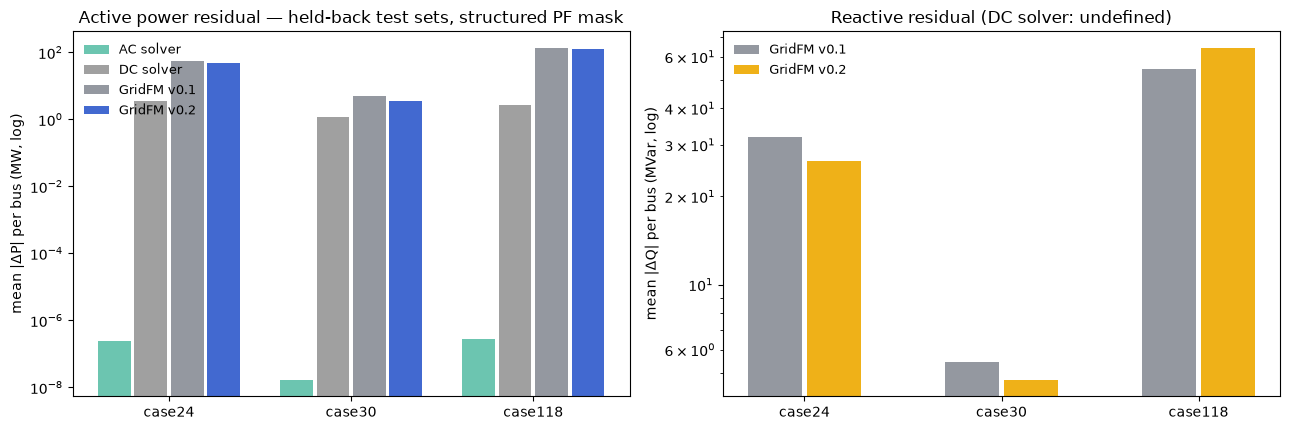

In [3]:
ac_res = {g: pd.read_csv(RAW_DIR / g / "meta.csv").set_index("scenario")
              .loc[[int(d.scenario) for d in test_v02[g]], "residual_mva"].mean()
          for g in GRIDS}
dc = {g: pd.read_csv(M5_STATS / ("dc_%s.csv" % g)) for g in GRIDS}
sc01 = pd.read_csv(M5_STATS / "scoreboard.csv", index_col=0)   # committed v0.1

score = pd.DataFrame({
    "AC solver Pr (MW)": {g: ac_res[g] for g in GRIDS},
    "DC solver Pr (MW)": {g: dc[g].p_res_mw.mean() for g in GRIDS},
    "GridFM v0.1 Pr (MW)": sc01["GridFM v0.1 Pr (MW)"],
    "GridFM v0.2 Pr (MW)": {g: res02[g].p_res_mw.mean() for g in GRIDS},
    "GridFM v0.1 Qr (MVar)": sc01["GridFM v0.1 Qr (MVar)"],
    "GridFM v0.2 Qr (MVar)": {g: res02[g].q_res_mvar.mean() for g in GRIDS},
})
print(score.round(4).to_string())
score.to_csv(STATS_DIR / "scoreboard.csv")

thesis = pd.DataFrame({
    "DC Pr": {"case24": 18.61, "case30": 3.99, "case118": 29.33},
    "v0.1 Pr": {"case24": 23.81, "case30": 4.986, "case118": 13.41},
    "v0.2 Pr": {"case24": 16.27, "case30": 2.991, "case118": 7.783},
    "v0.1 Qr": {"case24": 7.815, "case30": 2.308, "case118": 3.995},
    "v0.2 Qr": {"case24": 4.993, "case30": 2.312, "case118": 4.210},
})
print("\nThesis Tables 5.2/5.3 (450k samples, 4.8-7.4M params) for qualitative context:")
print(thesis.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
xpos = np.arange(len(GRIDS))
for k, (label, col) in enumerate([("AC solver Pr (MW)", "#6CC5B0"),
                                  ("DC solver Pr (MW)", "#A0A0A0"),
                                  ("GridFM v0.1 Pr (MW)", "#9498A0"),
                                  ("GridFM v0.2 Pr (MW)", "#4269D0")]):
    axes[0].bar(xpos + 0.2 * k, score[label].values, width=0.18, color=col,
                label=label.replace(" Pr (MW)", ""))
axes[0].set_yscale("log")
axes[0].set_xticks(xpos + 0.3); axes[0].set_xticklabels(GRIDS)
axes[0].set(ylabel="mean |ΔP| per bus (MW, log)",
            title="Active power residual — held-back test sets, structured PF mask")
axes[0].legend(frameon=False, fontsize=9)

for k, (label, col) in enumerate([("GridFM v0.1 Qr (MVar)", "#9498A0"),
                                  ("GridFM v0.2 Qr (MVar)", "#EFB118")]):
    axes[1].bar(xpos + 0.3 * k, score[label].values, width=0.27, color=col,
                label=label.replace(" Qr (MVar)", ""))
axes[1].set_yscale("log")
axes[1].set_xticks(xpos + 0.15); axes[1].set_xticklabels(GRIDS)
axes[1].set(ylabel="mean |ΔQ| per bus (MVar, log)",
            title="Reactive residual (DC solver: undefined)")
axes[1].legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_scoreboard.png", bbox_inches="tight", dpi=150)
plt.show()

## Scenario-by-scenario: does v0.2 win everywhere, or on average?

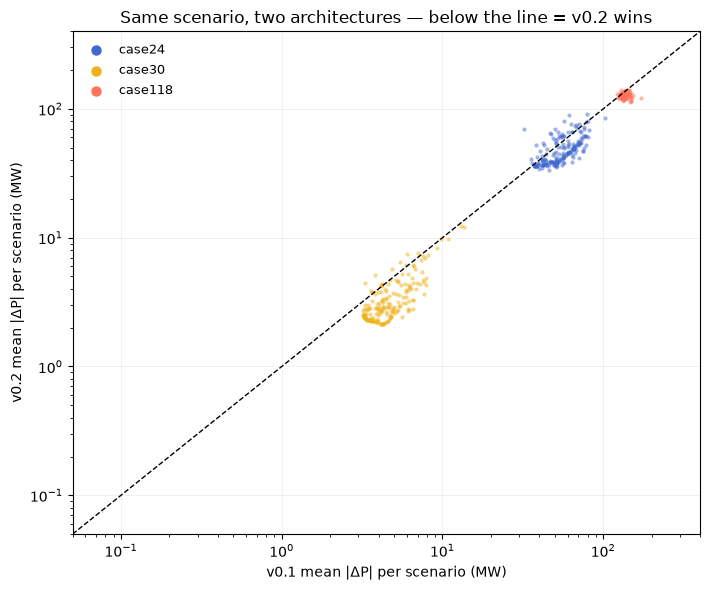

case24   v0.2 beats v0.1 on  79.0% of test scenarios

case30   v0.2 beats v0.1 on  92.9% of test scenarios

case118  v0.2 beats v0.1 on  92.6% of test scenarios

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 6))
frac_win = {}
for g in GRIDS:
    old = pd.read_csv(M5_STATS / ("gridfm_%s.csv" % g))[["scenario", "p_res_mw"]]
    both = old.merge(res02[g][["scenario", "p_res_mw"]], on="scenario",
                     suffixes=("_v01", "_v02"))
    ax.scatter(both.p_res_mw_v01, both.p_res_mw_v02, s=9, alpha=0.5, lw=0,
               color=GRID_COLORS[g], label=g)
    frac_win[g] = float((both.p_res_mw_v02 < both.p_res_mw_v01).mean())
lims = [0.05, 400]
ax.plot(lims, lims, "k--", lw=1)
ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims,
       xlabel="v0.1 mean |ΔP| per scenario (MW)", ylabel="v0.2 mean |ΔP| per scenario (MW)",
       title="Same scenario, two architectures — below the line = v0.2 wins")
leg = ax.legend(frameon=False, fontsize=9, markerscale=2.5)
for lh in leg.legend_handles:
    lh.set_alpha(1.0)
ax.grid(alpha=0.25, lw=0.5)
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_paired_scatter.png", bbox_inches="tight", dpi=150)
plt.show()
for g in GRIDS:
    print("%-8s v0.2 beats v0.1 on %5.1f%% of test scenarios" % (g, 100 * frac_win[g]))

## Do the predicted states look right? Masked-voltage scatter

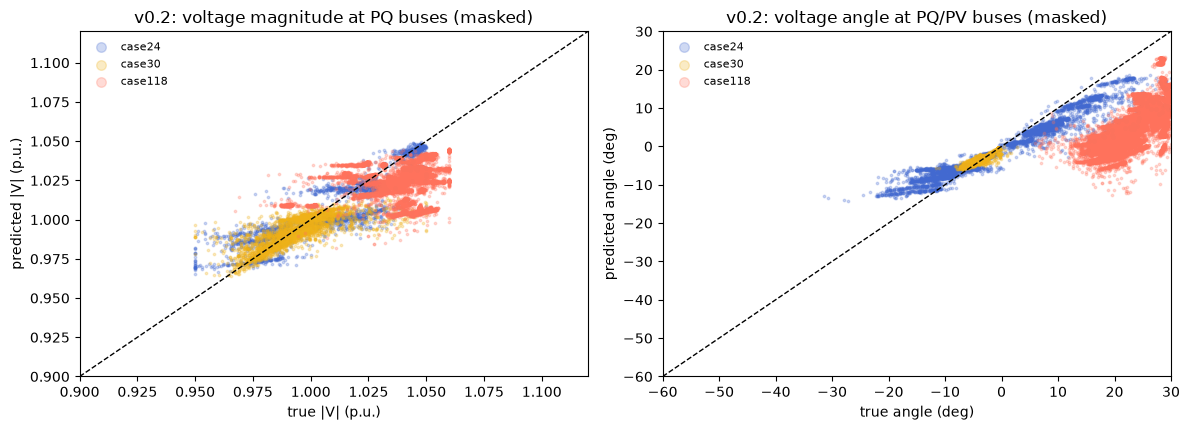

masked-feature errors, v0.2 vs v0.1 (fresh eval, same buses):

case24   v0.2 |V|: mean 0.0086 p.u. (p95 0.0241) | angle: mean 3.53 deg (p95 8.99)

case24   v0.1 |V|: mean 0.0114 p.u. (p95 0.0307) | angle: mean 5.11 deg (p95 12.71)

case30   v0.2 |V|: mean 0.0052 p.u. (p95 0.0190) | angle: mean 0.49 deg (p95 1.51)

case30   v0.1 |V|: mean 0.0074 p.u. (p95 0.0252) | angle: mean 1.14 deg (p95 3.04)

case118  v0.2 |V|: mean 0.0170 p.u. (p95 0.0357) | angle: mean 17.97 deg (p95 24.25)

case118  v0.1 |V|: mean 0.0161 p.u. (p95 0.0365) | angle: mean 12.37 deg (p95 26.70)

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for g in GRIDS:
    axes[0].scatter(det02[g]["vm_true"], det02[g]["vm_pred"], s=3, alpha=0.25,
                    color=GRID_COLORS[g], label=g)
    axes[1].scatter(np.rad2deg(det02[g]["va_true"]), np.rad2deg(det02[g]["va_pred"]),
                    s=3, alpha=0.25, color=GRID_COLORS[g], label=g)
lims0 = [0.90, 1.12]
axes[0].plot(lims0, lims0, "k--", lw=1)
axes[0].set(xlabel="true |V| (p.u.)", ylabel="predicted |V| (p.u.)",
            title="v0.2: voltage magnitude at PQ buses (masked)", xlim=lims0, ylim=lims0)
lims1 = [-60, 30]
axes[1].plot(lims1, lims1, "k--", lw=1)
axes[1].set(xlabel="true angle (deg)", ylabel="predicted angle (deg)",
            title="v0.2: voltage angle at PQ/PV buses (masked)", xlim=lims1, ylim=lims1)
for a in axes:
    a.legend(frameon=False, fontsize=8, markerscale=4)
fig.tight_layout(); fig.savefig(FIG_DIR / "f3_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

print("masked-feature errors, v0.2 vs v0.1 (fresh eval, same buses):")
for g in GRIDS:
    for tag, det in [("v0.2", det02[g]), ("v0.1", det01[g])]:
        vm_err = np.abs(np.array(det["vm_pred"]) - np.array(det["vm_true"]))
        va_err = np.rad2deg(np.abs(np.array(det["va_pred"]) - np.array(det["va_true"])))
        print("%-8s %s |V|: mean %.4f p.u. (p95 %.4f) | angle: mean %.2f deg (p95 %.2f)"
              % (g, tag, vm_err.mean(), np.percentile(vm_err, 95),
                 va_err.mean(), np.percentile(va_err, 95)))

## A voltage profile, the way an operator would read it

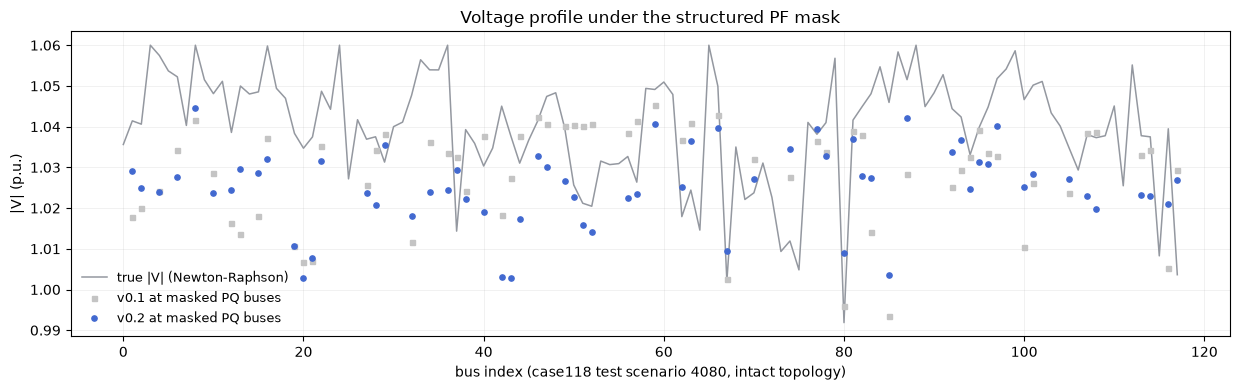

case118 masked-|V| MAE on this scenario: v0.1 0.0160 p.u. | v0.2 0.0164 p.u.

In [6]:
i118 = next(i for i, gr in enumerate(test_plain["case118"]) if gr.n_removed == 0)
g_plain = test_plain["case118"][i118]
# pf_evaluate moved the stored v0.2 graphs to the GPU in place; bring a copy back
g_v02 = test_v02["case118"][i118].clone().to("cpu")
assert int(g_plain.scenario) == int(g_v02.scenario)

xm1, m1 = ds.pf_mask(g_plain.x)
xm2, m2 = ds.pf_mask(g_v02.x)
model_v01.eval(); m02 = model_v02.to("cpu").eval()
with torch.no_grad():
    p1 = model_v01(xm1, g_plain.edge_index, g_plain.edge_attr)
    p2 = m02(xm2, g_v02.edge_index, g_v02.edge_attr)
vm_true = g_plain.x[:, 4].numpy()
idx = np.where(m1[:, 4].numpy())[0]

fig, ax = plt.subplots(figsize=(12.5, 4.0))
ax.plot(vm_true, "-", color="#9498A0", lw=1.1, label="true |V| (Newton-Raphson)")
ax.plot(idx, p1[idx, 4].numpy(), "s", color="#C4C4C4", ms=3.6, label="v0.1 at masked PQ buses")
ax.plot(idx, p2[idx, 4].numpy(), "o", color="#4269D0", ms=3.8, label="v0.2 at masked PQ buses")
ax.set(xlabel="bus index (case118 test scenario %d, intact topology)" % int(g_plain.scenario),
       ylabel="|V| (p.u.)", title="Voltage profile under the structured PF mask")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25, lw=0.5)
fig.tight_layout(); fig.savefig(FIG_DIR / "f4_voltage_profile.png", bbox_inches="tight", dpi=150)
plt.show()
mae1 = float(np.abs(p1[idx, 4].numpy() - vm_true[idx]).mean())
mae2 = float(np.abs(p2[idx, 4].numpy() - vm_true[idx]).mean())
print("case118 masked-|V| MAE on this scenario: v0.1 %.4f p.u. | v0.2 %.4f p.u." % (mae1, mae2))

## Where do the remaining errors live?

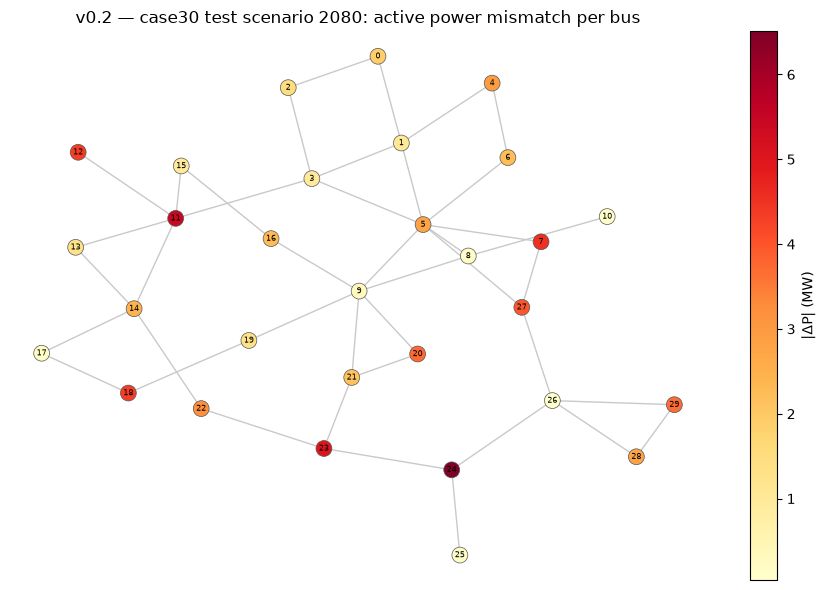

{
  "frac_scenarios_v02_beats_v01": {
    "case24": 0.7903225806451613,
    "case30": 0.9285714285714286,
    "case118": 0.925531914893617
  },
  "case118_profile_mae": {
    "v01": 0.01596078649163246,
    "v02": 0.016405265778303146
  },
  "thesis_pattern": "v0.2 expected to win Pr everywhere, give back a little Qr"
}

In [7]:
import networkx as nx
import pandapower.topology as top
from gridfm.datagen import build_net

i30 = next(i for i, gr in enumerate(test_plain["case30"]) if gr.n_removed == 0)
_, _, (dp_bus, sid30) = ev.pf_evaluate(model_v02.to(DEVICE), [test_v02["case30"][i30]],
                                       device=DEVICE)

net30 = build_net("case30")
G = top.create_nxgraph(net30)
pos = nx.kamada_kawai_layout(G)
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in net30.line.iterrows():
    ax.plot([pos[row.from_bus][0], pos[row.to_bus][0]],
            [pos[row.from_bus][1], pos[row.to_bus][1]], "-", color="#C9C9C9", lw=1, zorder=0)
for _, row in net30.trafo.iterrows():
    ax.plot([pos[row.hv_bus][0], pos[row.lv_bus][0]],
            [pos[row.hv_bus][1], pos[row.lv_bus][1]], "-", color="#8A8A8A", lw=1.4, zorder=0)
sc = ax.scatter([pos[b][0] for b in G.nodes], [pos[b][1] for b in G.nodes],
                c=[dp_bus[b] for b in G.nodes], cmap="YlOrRd", s=130, zorder=2,
                edgecolor="#555555", lw=0.5)
for b in G.nodes:
    ax.annotate(str(b), pos[b], ha="center", va="center", fontsize=6, zorder=3)
plt.colorbar(sc, ax=ax, label="|ΔP| (MW)")
ax.set_title("v0.2 — case30 test scenario %d: active power mismatch per bus" % sid30)
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "f5_error_map.png", bbox_inches="tight", dpi=150)
plt.show()

summary = {
    "scoreboard": json.loads(score.to_json()),
    "frac_scenarios_v02_beats_v01": frac_win,
    "case118_profile_mae": {"v01": mae1, "v02": mae2},
    "thesis_pattern": "v0.2 expected to win Pr everywhere, give back a little Qr",
}
with open(STATS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps({k: v for k, v in summary.items() if k != "scoreboard"}, indent=2))